# Brokering in the Headlines: How Dawn and the Guardian Construct Pakistan's Mediator Role in the 2025–2026 US–Iran Conflict

**Research question:** How is Pakistan's role as a mediator in the 2025–2026 US–Iran conflict represented in news discourse, and how has its represented centrality between the US and Iran shifted across the pre-talks, war/mediation, and post-ceasefire phases?

**Framework:** Co-occurrence analysis (keyword pairing within article bodies) is used as a proxy for *discursive centrality* — how often Pakistan is textually linked to mediation-related, conflict-related, and trade-related terms, relative to other state actors, across three analytical phases. Dawn and the Guardian are analyzed **separately** throughout (not pooled), since the research question is about how each outlet individually constructs Pakistan's role.

| Phase | Label | Date range |
|---|---|---|
| 1 | Pre-talks | 2025-10-01 → 2026-02-27 |
| 2 | War + Pakistan-mediated ceasefire (Islamabad Talks) | 2026-02-28 → 2026-05-31 |
| 3 | Post-ceasefire / final deal | 2026-06-01 → 2026-06-30 |


## 1. Setup and Data Loading (Dawn and Guardian kept separate)

Both CSVs are loaded into **two independent dataframes** — `df_dawn` and `df_guardian` — and are *not* concatenated. Every downstream step (filtering, phase assignment, keyword matrices, charts) is run on each outlet independently so the two news sources can be compared rather than blended.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

sns.set_theme(style="whitegrid")
pd.set_option('display.max_colwidth', 80)

DAWN_URL = "https://raw.githubusercontent.com/smsali97/pak-news-analysis/refs/heads/main/dawn_intl.csv"
GUARDIAN_URL = "https://raw.githubusercontent.com/smsali97/pak-news-analysis/refs/heads/main/guardian_news.csv"

df_dawn = pd.read_csv(DAWN_URL)
df_guardian = pd.read_csv(GUARDIAN_URL)

for name, d in [('Dawn', df_dawn), ('Guardian', df_guardian)]:
    d['date'] = pd.to_datetime(d['date'])
    d.dropna(subset=['body'], inplace=True)
    d['body'] = d['body'].astype(str)
    print(f"{name}: {len(d)} articles, {d['date'].min().date()} -> {d['date'].max().date()}")


Dawn: 3626 articles, 2025-10-06 -> 2026-06-15
Guardian: 1605 articles, 2025-10-08 -> 2026-06-16


## 2. Filtering to Iran/USA-Related Articles

Both datasets contain a lot of unrelated news (UK politics, sport, obituaries, etc.) alongside conflict coverage. Per the project's filtering requirement, each dataset is filtered down to **only articles whose body mentions IRAN or USA** (case-insensitive), discarding everything else before any further analysis. This filtering is applied to `df_dawn` and `df_guardian` independently.

In [3]:
def filter_iran_or_usa(dataframe):
    """Keep only articles whose body mentions IRAN or USA (case-insensitive)."""
    mask = (
        dataframe['body'].str.contains('iran', case=False, na=False) |
        dataframe['body'].str.contains('usa', case=False, na=False) |
        dataframe['body'].str.contains(r'\bU\.S\.?A?\.?\b', case=False, na=False, regex=True) |
        dataframe['body'].str.contains('united states', case=False, na=False)
    )
    return dataframe[mask].copy()

df_dawn_filtered = filter_iran_or_usa(df_dawn)
df_guardian_filtered = filter_iran_or_usa(df_guardian)

print(f"Dawn: {len(df_dawn)} -> {len(df_dawn_filtered)} articles after IRAN/USA filter "
      f"({len(df_dawn_filtered)/len(df_dawn)*100:.1f}% retained)")
print(f"Guardian: {len(df_guardian)} -> {len(df_guardian_filtered)} articles after IRAN/USA filter "
      f"({len(df_guardian_filtered)/len(df_guardian)*100:.1f}% retained)")


Dawn: 3626 -> 2185 articles after IRAN/USA filter (60.3% retained)
Guardian: 1605 -> 1529 articles after IRAN/USA filter (95.3% retained)


## 3. Saving the Filtered Datasets to CSV

The filtered datasets are saved as standalone CSV files so they can be uploaded to the project's GitHub repo and reused without re-running the filter. One file per outlet (kept separate, matching the rest of the notebook).

In [4]:
df_dawn_filtered.to_csv('dawn_intl_iran_usa_filtered.csv', index=False)
df_guardian_filtered.to_csv('guardian_news_iran_usa_filtered.csv', index=False)

print("Saved: dawn_intl_iran_usa_filtered.csv")
print("Saved: guardian_news_iran_usa_filtered.csv")


Saved: dawn_intl_iran_usa_filtered.csv
Saved: guardian_news_iran_usa_filtered.csv


In [5]:
df_guardian_filtered.head()

,outlet,section,date,timestamp,author,headline,url,article_id,body
0,guardian,world,2025-10-08,2025-10-08T16:58:40Z,NaN,Iran has taken care of millions of Afghan refugees with little international...,https://www.theguardian.com/world/2025/oct/08/iran-has-taken-care-of-million...,world/2025/oct/08/iran-has-taken-care-of-millions-of-afghan-refugees-with-li...,"For more than four decades, the Islamic Republic of Iran has hosted millions..."
1,guardian,theguardian,2025-10-10,2025-10-10T16:55:00Z,Martin Crill,Maureen Crill obituary,https://www.theguardian.com/theguardian/2025/oct/10/maureen-crill-obituary,theguardian/2025/oct/10/maureen-crill-obituary,"My wife, Maureen Crill, who has died aged 68 from complications of a rare au..."
2,guardian,world,2025-10-11,2025-10-11T05:00:15Z,Sirin Kale,"‘To the men who ran the world, I was just a photo op’: Malala Yousafzai on g...",https://www.theguardian.com/world/2025/oct/11/malala-yousafzai-growing-up-ge...,world/2025/oct/11/malala-yousafzai-growing-up-getting-cynical-how-getting-hi...,I am at the shed where Nobel laureate Malala Yousafzai smoked her first bong...
3,guardian,world,2025-10-12,2025-10-12T12:29:38Z,Haroon Janjua and Shah Meer Baloch in Islamabad and Hannah Ellis-Petersen i...,Heavy clashes erupt along Pakistan-Afghanistan border,https://www.theguardian.com/world/2025/oct/11/heavy-clashes-erupt-along-paki...,world/2025/oct/11/heavy-clashes-erupt-along-pakistan-afghanistan-border,Intense clashes erupted along the Pakistan-Afghanistan border on Saturday ni...
4,guardian,world,2025-10-13,2025-10-13T09:31:24Z,"Hannah Ellis-Petersen South Asia correspondent, and Shah Meer Baloch in Pesh...",‘An environment of terror’: deadly resurgence of Pakistan Taliban gathers pace,https://www.theguardian.com/world/2025/oct/13/an-environment-of-terror-deadl...,world/2025/oct/13/an-environment-of-terror-deadly-resurgence-of-pakistan-tal...,Tariq Ahmed never lets his pistol out of his sight these days. Sitting cross...


## 4. Defining the Three Research Phases

Phase boundaries are applied to each *filtered* dataset independently.

In [6]:
PHASE_BOUNDS = {
    "Phase 1: Pre-talks":                  (pd.Timestamp("2025-10-01"), pd.Timestamp("2026-02-27")),
    "Phase 2: War + Islamabad Talks":       (pd.Timestamp("2026-02-28"), pd.Timestamp("2026-05-31")),
    "Phase 3: Post-ceasefire / Final deal": (pd.Timestamp("2026-06-01"), pd.Timestamp("2026-06-30")),
}

def assign_phase(d):
    for label, (start, end) in PHASE_BOUNDS.items():
        if start <= d <= end:
            return label
    return "Out of range"

def add_phase_column(dataframe):
    dataframe = dataframe.copy()
    dataframe['phase'] = dataframe['date'].apply(assign_phase)
    dataframe = dataframe[dataframe['phase'] != "Out of range"].copy()
    dataframe['phase'] = pd.Categorical(dataframe['phase'], categories=list(PHASE_BOUNDS.keys()), ordered=True)
    return dataframe

df_dawn_filtered = add_phase_column(df_dawn_filtered)
df_guardian_filtered = add_phase_column(df_guardian_filtered)

print("Dawn (filtered) articles per phase:")
print(df_dawn_filtered['phase'].value_counts().reindex(list(PHASE_BOUNDS.keys())))
print("\nGuardian (filtered) articles per phase:")
print(df_guardian_filtered['phase'].value_counts().reindex(list(PHASE_BOUNDS.keys())))


Dawn (filtered) articles per phase:
phase
Phase 1: Pre-talks                      1109
Phase 2: War + Islamabad Talks           963
Phase 3: Post-ceasefire / Final deal     113
Name: count, dtype: int64

Guardian (filtered) articles per phase:
phase
Phase 1: Pre-talks                       193
Phase 2: War + Islamabad Talks          1255
Phase 3: Post-ceasefire / Final deal      81
Name: count, dtype: int64


## 5. Keyword Set

Keywords cover the core conflict actors, Pakistan/mediation-specific terms, competing regional mediators, process/outcome terms, and trade/economic terms — needed to study what increases or decreases Pakistan's represented mediator influence.

In [7]:
keywords = [
    # Core conflict actors
    'IRAN', 'USA', 'ISRAEL', 'PALESTINE', 'RUSSIA', 'CHINA', 'EUROPE',
    # Pakistan / mediation-specific
    'PAKISTAN', 'ISLAMABAD', 'MEDIATOR', 'MEDIATION', 'BACK-CHANNEL', 'BROKER',
    # Competing/alternative mediators
    'QATAR', 'SAUDI ARABIA', 'TURKEY', 'UAE',
    # Process / outcome terms
    'CEASEFIRE', 'TALKS', 'DIPLOMACY', 'PEACE', 'WAR', 'CONFLICT',
    'SANCTIONS', 'NUCLEAR', 'SECURITY', 'MILITARY',
    # Trade / economic terms
    'TRADE', 'OIL', 'ECONOMY', 'SANCTIONS RELIEF',
]

print(f"Total keywords tracked: {len(keywords)}")


Total keywords tracked: 31


## 6. Co-occurrence Matrix Construction

Run separately per outlet per phase — six matrices total (2 outlets × 3 phases) — all built on the **filtered** (IRAN/USA-mentioning) data.

In [8]:
def build_keyword_cooccurrence_matrix(dataframe, keywords):
    """Builds a symmetric keyword x keyword co-occurrence matrix
    based on presence of each keyword (case-insensitive) in the article body."""
    matrix = pd.DataFrame(0, index=keywords, columns=keywords)
    bodies_lower = dataframe['body'].str.lower()
    presence = pd.DataFrame({kw: bodies_lower.str.contains(kw.lower(), regex=False, na=False) for kw in keywords})

    for i, kw1 in enumerate(keywords):
        for kw2 in keywords[i+1:]:
            count = int((presence[kw1] & presence[kw2]).sum())
            matrix.loc[kw1, kw2] = count
            matrix.loc[kw2, kw1] = count
    return matrix

dawn_phase_matrices = {}
guardian_phase_matrices = {}

for phase_label in PHASE_BOUNDS.keys():
    dawn_phase_matrices[phase_label] = build_keyword_cooccurrence_matrix(
        df_dawn_filtered[df_dawn_filtered['phase'] == phase_label], keywords)
    guardian_phase_matrices[phase_label] = build_keyword_cooccurrence_matrix(
        df_guardian_filtered[df_guardian_filtered['phase'] == phase_label], keywords)
    print(f"{phase_label}: Dawn={ (df_dawn_filtered['phase']==phase_label).sum() } articles, "
          f"Guardian={ (df_guardian_filtered['phase']==phase_label).sum() } articles -> matrices built")


Phase 1: Pre-talks: Dawn=1109 articles, Guardian=193 articles -> matrices built
Phase 2: War + Islamabad Talks: Dawn=963 articles, Guardian=1255 articles -> matrices built
Phase 3: Post-ceasefire / Final deal: Dawn=113 articles, Guardian=81 articles -> matrices built


## 7. Visualization 1 — Co-occurrence Heatmaps per Outlet, per Phase

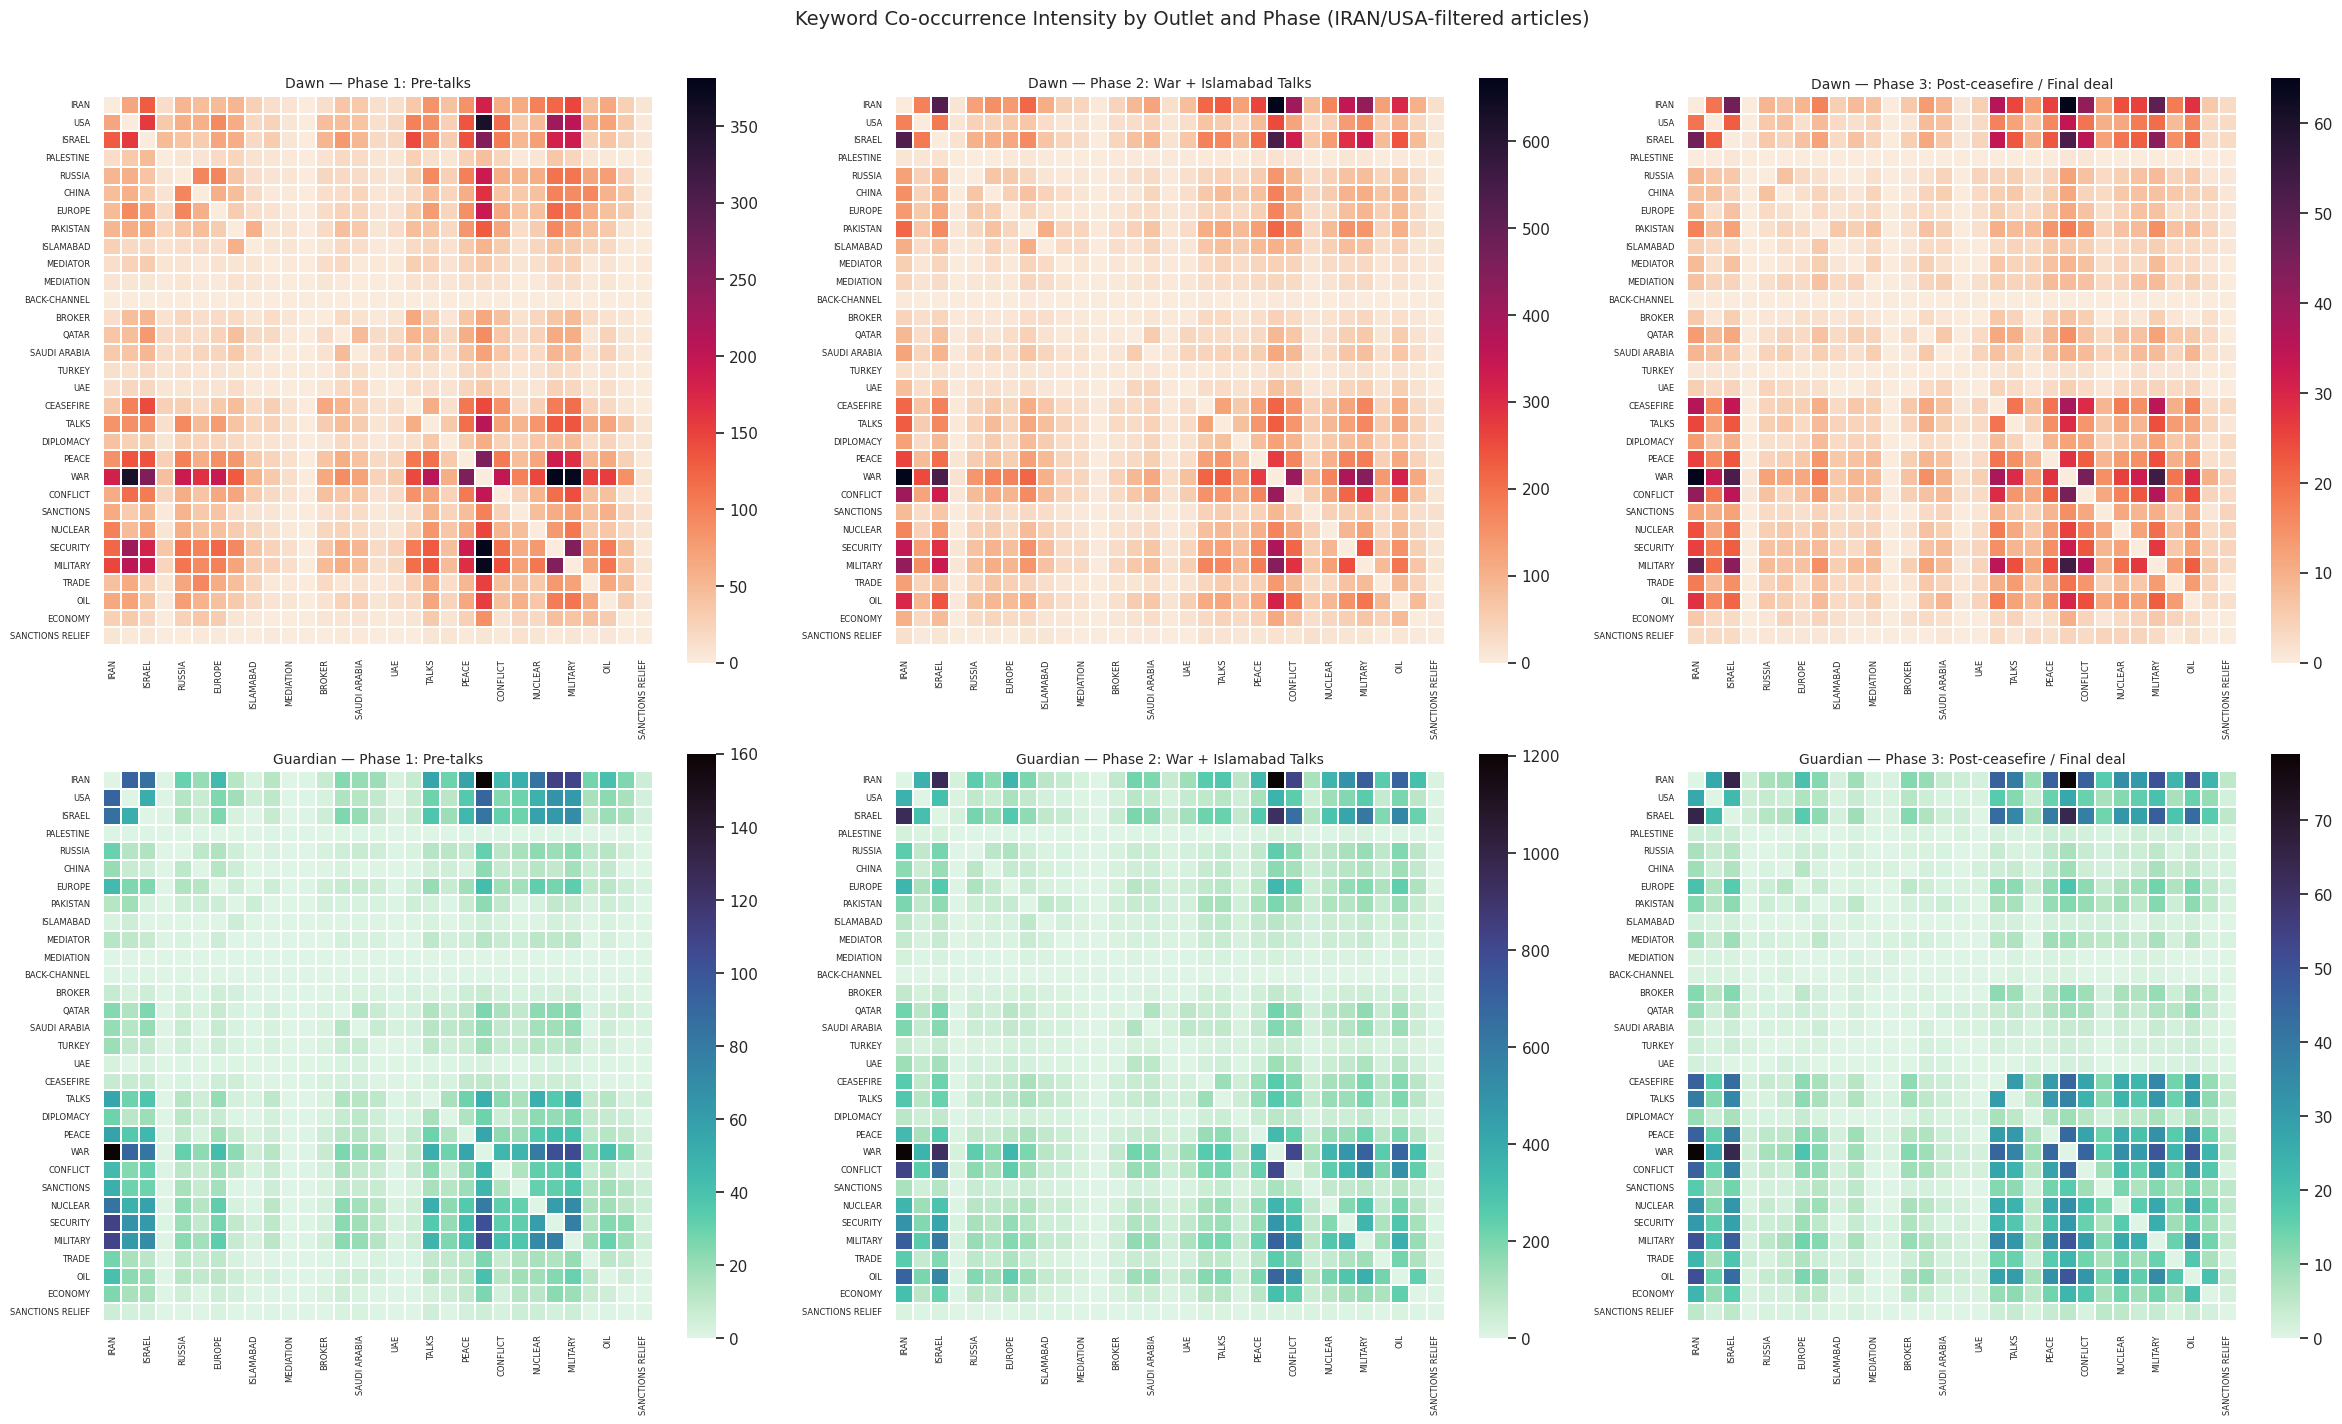

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(24, 14))

for col, (phase_label, matrix) in enumerate(dawn_phase_matrices.items()):
    sns.heatmap(matrix, ax=axes[0, col], cmap="rocket_r", cbar=True, square=True, linewidths=0.3, linecolor='white')
    axes[0, col].set_title(f"Dawn — {phase_label}", fontsize=10)
    axes[0, col].tick_params(axis='x', rotation=90, labelsize=6)
    axes[0, col].tick_params(axis='y', rotation=0, labelsize=6)

for col, (phase_label, matrix) in enumerate(guardian_phase_matrices.items()):
    sns.heatmap(matrix, ax=axes[1, col], cmap="mako_r", cbar=True, square=True, linewidths=0.3, linecolor='white')
    axes[1, col].set_title(f"Guardian — {phase_label}", fontsize=10)
    axes[1, col].tick_params(axis='x', rotation=90, labelsize=6)
    axes[1, col].tick_params(axis='y', rotation=0, labelsize=6)

plt.suptitle("Keyword Co-occurrence Intensity by Outlet and Phase (IRAN/USA-filtered articles)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## 8. Pakistan's Affiliation with Key Terms Across the Three Phases (Filtered Data)

This directly answers the project's third requirement: how Pakistan's textual affiliation with mediation, conflict-party, and trade terms shifts across the three phases — computed separately for each outlet on the IRAN/USA-filtered dataset.

In [10]:
affiliation_terms = ['IRAN', 'USA', 'MEDIATION', 'CEASEFIRE', 'BROKER', 'TALKS',
                      'ISLAMABAD', 'DIPLOMACY', 'TRADE', 'OIL', 'SANCTIONS']

def pakistan_affiliation_table(phase_matrices):
    rows = []
    for phase_label, matrix in phase_matrices.items():
        row = {'phase': phase_label}
        for term in affiliation_terms:
            row[term] = matrix.loc['PAKISTAN', term]
        rows.append(row)
    return pd.DataFrame(rows).set_index('phase')

dawn_pakistan_affiliation = pakistan_affiliation_table(dawn_phase_matrices)
guardian_pakistan_affiliation = pakistan_affiliation_table(guardian_phase_matrices)

print("Dawn — Pakistan affiliation with key terms by phase:")
display(dawn_pakistan_affiliation)

print("\nGuardian — Pakistan affiliation with key terms by phase:")
display(guardian_pakistan_affiliation)


Dawn — Pakistan affiliation with key terms by phase:


,IRAN,USA,MEDIATION,CEASEFIRE,BROKER,TALKS,ISLAMABAD,DIPLOMACY,TRADE,OIL,SANCTIONS
phase,,,,,,,,,,,
Phase 1: Pre-talks,53,62,10,46,17,40,57,18,46,34,14
Phase 2: War + Islamabad Talks,214,65,38,105,25,113,105,83,40,101,33
Phase 3: Post-ceasefire / Final deal,17,8,7,10,2,8,6,8,7,8,4



Guardian — Pakistan affiliation with key terms by phase:


,IRAN,USA,MEDIATION,CEASEFIRE,BROKER,TALKS,ISLAMABAD,DIPLOMACY,TRADE,OIL,SANCTIONS
phase,,,,,,,,,,,
Phase 1: Pre-talks,12,18,0,5,4,4,6,1,3,6,1
Phase 2: War + Islamabad Talks,194,68,18,122,37,121,76,36,53,142,49
Phase 3: Post-ceasefire / Final deal,12,6,0,8,2,8,2,1,3,11,6


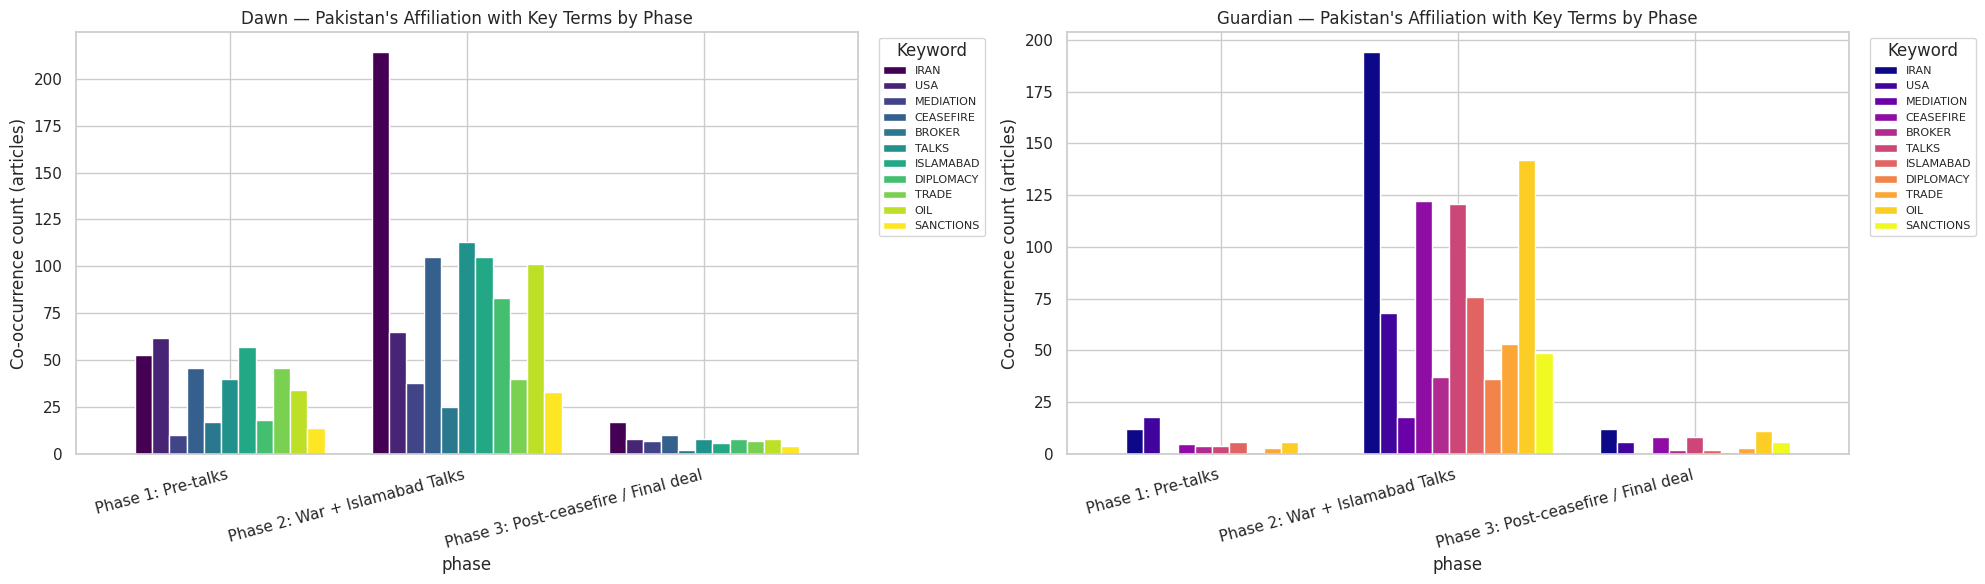

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=False)

dawn_pakistan_affiliation.plot(kind='bar', ax=axes[0], width=0.8, colormap='viridis')
axes[0].set_title("Dawn — Pakistan's Affiliation with Key Terms by Phase")
axes[0].set_ylabel("Co-occurrence count (articles)")
axes[0].set_xticklabels(dawn_pakistan_affiliation.index, rotation=15, ha='right')
axes[0].legend(title="Keyword", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

guardian_pakistan_affiliation.plot(kind='bar', ax=axes[1], width=0.8, colormap='plasma')
axes[1].set_title("Guardian — Pakistan's Affiliation with Key Terms by Phase")
axes[1].set_ylabel("Co-occurrence count (articles)")
axes[1].set_xticklabels(guardian_pakistan_affiliation.index, rotation=15, ha='right')
axes[1].legend(title="Keyword", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()


## 9. Free-Text Word Frequency: Words Unique to Each Phase vs. Shared

Instead of relying only on the fixed keyword list, this section extracts the **actual most frequent words** from article bodies in each phase (tokenizing raw text, not a predefined vocabulary), then compares the three phases to find:

- **Words distinctive to each phase** (frequent in that phase, comparatively rare in the other two)
- **Shared/common words** filtered out — both standard English stopwords (the, and, was...) and a custom **Pakistan-news boilerplate list** (generic terms that appear constantly regardless of phase, e.g. "pakistan", "said", "government", "minister", "country", "news") since these would otherwise dominate all three phases and hide the actually meaningful shifts.

Run separately for Dawn and Guardian, on the IRAN/USA-filtered data, using the same `df_dawn_filtered` / `df_guardian_filtered` / `PHASE_BOUNDS` already defined above.

In [12]:
import re
from collections import Counter

# Standard English stopwords (compact built-in list; avoids needing nltk download)
ENGLISH_STOPWORDS = set('''
a about above after again against all am an and any are aren't as at be because been
before being below between both but by can't cannot could couldn't did didn't do does
doesn't doing don't down during each few for from further had hadn't has hasn't have
haven't having he he'd he'll he's her here here's hers herself him himself his how
how's i i'd i'll i'm i've if in into is isn't it it's its itself let's me more most
mustn't my myself no nor not of off on once only or other ought our ours ourselves out
over own same shan't she she'd she'll she's should shouldn't so some such than that
that's the their theirs them themselves then there there's these they they'd they'll
they're they've this those through to too under until up very was wasn't we we'd
we'll we're we've were weren't what what's when when's where where's which while who
who's whom why why's with won't would wouldn't you you'd you'll you're you've your
yours yourself yourselves
'''.split())

# Custom boilerplate list: generic Pakistan/news-reporting terms expected to appear
# constantly across ALL phases, which would otherwise mask the phase-distinctive signal
PAKISTAN_NEWS_BOILERPLATE = set('''
pakistan pakistani pakistans said says say according government minister ministry
president prime news report reported reporters reporting statement officials official
country countries state states national international foreign affairs spokesperson
told tuesday wednesday thursday friday monday sunday saturday week month year years
also one two three new will would could may might still even since
'''.split())

STOP_AND_BOILERPLATE = ENGLISH_STOPWORDS | PAKISTAN_NEWS_BOILERPLATE

def tokenize(text):
    """Lowercase, strip punctuation/numbers, split into word tokens of length > 2."""
    text = text.lower()
    words = re.findall(r"[a-z]+", text)
    return [w for w in words if len(w) > 2 and w not in STOP_AND_BOILERPLATE]

def phase_word_freq(dataframe, phase_label):
    phase_text = ' '.join(dataframe.loc[dataframe['phase'] == phase_label, 'body'])
    tokens = tokenize(phase_text)
    return Counter(tokens)

dawn_freq3 = {p: phase_word_freq(df_dawn_filtered, p) for p in PHASE_BOUNDS.keys()}
guardian_freq3 = {p: phase_word_freq(df_guardian_filtered, p) for p in PHASE_BOUNDS.keys()}

for outlet_name, freqs in [('Dawn', dawn_freq3), ('Guardian', guardian_freq3)]:
    for phase_label, counter in freqs.items():
        print(f"{outlet_name} — {phase_label}: top 8 -> {counter.most_common(8)}")
    print()


Dawn — Phase 1: Pre-talks: top 8 -> [('trump', 3433), ('united', 1599), ('israel', 1534), ('gaza', 1338), ('people', 1330), ('iran', 1318), ('military', 1180), ('israeli', 1069)]
Dawn — Phase 2: War + Islamabad Talks: top 8 -> [('iran', 4142), ('trump', 2660), ('war', 2327), ('israel', 1556), ('military', 1496), ('iranian', 1481), ('israeli', 1459), ('united', 1127)]
Dawn — Phase 3: Post-ceasefire / Final deal: top 8 -> [('iran', 523), ('trump', 349), ('israel', 255), ('war', 221), ('israeli', 195), ('military', 180), ('iranian', 173), ('lebanon', 164)]

Guardian — Phase 1: Pre-talks: top 8 -> [('iran', 1687), ('trump', 828), ('iranian', 683), ('people', 585), ('protests', 405), ('tehran', 349), ('protesters', 346), ('nuclear', 335)]
Guardian — Phase 2: War + Islamabad Talks: top 8 -> [('iran', 8672), ('trump', 5307), ('war', 5107), ('oil', 2904), ('israel', 2781), ('iranian', 2680), ('strait', 2217), ('people', 2188)]
Guardian — Phase 3: Post-ceasefire / Final deal: top 8 -> [('iran',

In [22]:
# def unique_vs_shared_3phase(freq_dict, phase_labels, top_n=20, min_count=5):
#     """For each phase, computes a distinctiveness score as the log-ratio of that phase's
#     relative frequency vs. the average relative frequency of the other two phases.
#     Returns one 'unique' table per phase plus one shared table."""
#     totals = {p: sum(freq_dict[p].values()) for p in phase_labels}
#     vocab = set()
#     for p in phase_labels:
#         vocab |= set(freq_dict[p])

#     rows = []
#     for word in vocab:
#         counts = {p: freq_dict[p].get(word, 0) for p in phase_labels}
#         if max(counts.values()) < min_count:
#             continue
#         rel = {p: (counts[p] / totals[p] if totals[p] else 0) for p in phase_labels}
#         row = {'word': word}
#         for p in phase_labels:
#             row[f'count_{p}'] = counts[p]
#         for p in phase_labels:
#             others = [rel[q] for q in phase_labels if q != p]
#             other_mean = np.mean(others) if others else 0
#             row[f'distinct_{p}'] = np.log((rel[p] + 1e-7) / (other_mean + 1e-7))
#         rows.append(row)

#     result_df = pd.DataFrame(rows)

#     unique_tables = {}
#     for p in phase_labels:
#         unique_tables[p] = result_df.sort_values(f'distinct_{p}', ascending=False).head(top_n)

#     distinct_cols = [f'distinct_{p}' for p in phase_labels]
#     result_df['max_abs_distinct'] = result_df[distinct_cols].abs().max(axis=1)
#     shared = result_df.sort_values('max_abs_distinct').head(top_n)

#     return unique_tables, shared

# dawn_unique3, dawn_shared3 = unique_vs_shared_3phase(dawn_freq3, list(PHASE_BOUNDS.keys()))

# for phase_label, table in dawn_unique3.items():
#     print(f"Dawn — words distinctive to {phase_label}:")
#     display(table[['word'] + [c for c in table.columns if c.startswith('count_')]])
#     print()

# print("Dawn — words SHARED across all three phases:")
# display(dawn_shared3[['word'] + [c for c in dawn_shared3.columns if c.startswith('count_')]])


In [21]:
# guardian_unique3, guardian_shared3 = unique_vs_shared_3phase(guardian_freq3, list(PHASE_BOUNDS.keys()))

# for phase_label, table in guardian_unique3.items():
#     print(f"Guardian — words distinctive to {phase_label}:")
#     display(table[['word'] + [c for c in table.columns if c.startswith('count_')]])
#     print()

# print("Guardian — words SHARED across all three phases:")
# display(guardian_shared3[['word'] + [c for c in guardian_shared3.columns if c.startswith('count_')]])


### 9.1 Visualization — Distinctive Words by Phase (Dawn vs. Guardian)

In [20]:
# fig, axes = plt.subplots(2, 3, figsize=(24, 13))

# phase_labels_3 = list(PHASE_BOUNDS.keys())
# phase_colors = ['#7f8c8d', '#2980b9', '#27ae60']

# for col, phase_label in enumerate(phase_labels_3):
#     top = dawn_unique3[phase_label].nlargest(12, f'count_{phase_label}')
#     axes[0, col].barh(top['word'], top[f'count_{phase_label}'], color=phase_colors[col])
#     axes[0, col].set_title(f"Dawn — distinctive to\n{phase_label}", fontsize=10)
#     axes[0, col].invert_yaxis()

# for col, phase_label in enumerate(phase_labels_3):
#     top = guardian_unique3[phase_label].nlargest(12, f'count_{phase_label}')
#     axes[1, col].barh(top['word'], top[f'count_{phase_label}'], color=phase_colors[col])
#     axes[1, col].set_title(f"Guardian — distinctive to\n{phase_label}", fontsize=10)
#     axes[1, col].invert_yaxis()

# plt.suptitle("Phase-Distinctive Vocabulary (stopwords and Pakistan-news boilerplate removed)",
#               fontsize=14, y=1.02)
# plt.tight_layout()
# plt.show()


## 10. Influence Index (Co-occurrence-Frequency-Based), per Outlet

`Influence Index = PAKISTAN co-occurrence with {MEDIATION, CEASEFIRE, BROKER, TALKS, ISLAMABAD}`, summed per phase and normalized per 100 filtered articles, computed separately for Dawn and Guardian.

In [16]:
mediation_terms = ['MEDIATION', 'CEASEFIRE', 'BROKER', 'TALKS', 'ISLAMABAD']

def influence_index_table(phase_matrices, filtered_df):
    rows = []
    for phase_label, matrix in phase_matrices.items():
        n_articles = (filtered_df['phase'] == phase_label).sum()
        raw_score = matrix.loc['PAKISTAN', mediation_terms].sum()
        normalized = (raw_score / n_articles * 100) if n_articles else 0
        rows.append({'phase': phase_label, 'n_articles': n_articles,
                      'raw_influence_score': raw_score,
                      'influence_index_per_100_articles': round(normalized, 2)})
    return pd.DataFrame(rows).set_index('phase')

dawn_influence_df = influence_index_table(dawn_phase_matrices, df_dawn_filtered)
guardian_influence_df = influence_index_table(guardian_phase_matrices, df_guardian_filtered)

print("Dawn influence index:")
display(dawn_influence_df)
print("\nGuardian influence index:")
display(guardian_influence_df)


Dawn influence index:


,n_articles,raw_influence_score,influence_index_per_100_articles
phase,,,
Phase 1: Pre-talks,1109,170,15.33
Phase 2: War + Islamabad Talks,963,386,40.08
Phase 3: Post-ceasefire / Final deal,113,33,29.20



Guardian influence index:


,n_articles,raw_influence_score,influence_index_per_100_articles
phase,,,
Phase 1: Pre-talks,193,19,9.84
Phase 2: War + Islamabad Talks,1255,374,29.80
Phase 3: Post-ceasefire / Final deal,81,20,24.69


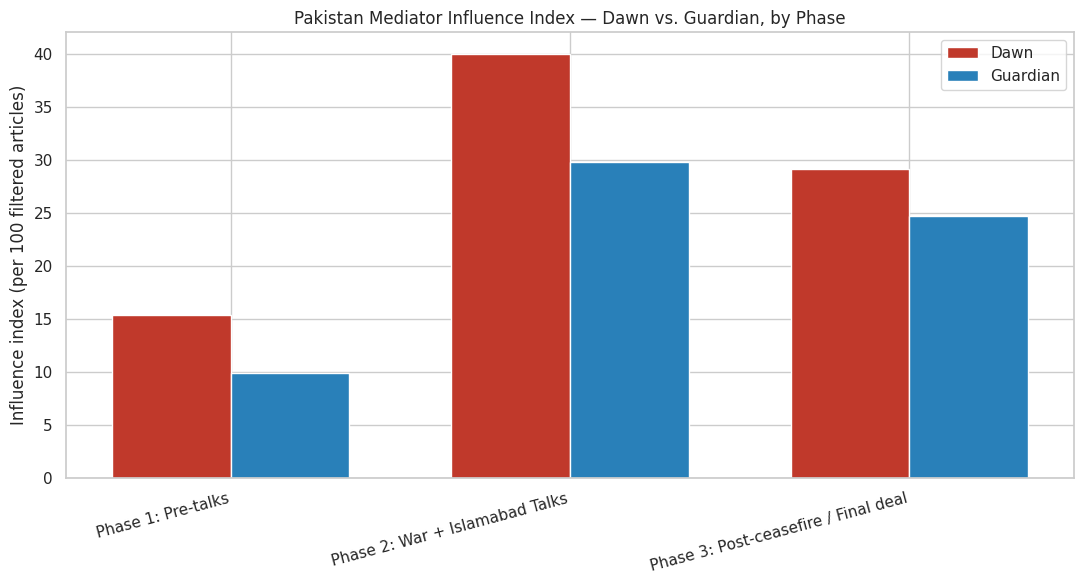

In [17]:
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(PHASE_BOUNDS))
width = 0.35

ax.bar(x - width/2, dawn_influence_df['influence_index_per_100_articles'], width, label='Dawn', color='#c0392b')
ax.bar(x + width/2, guardian_influence_df['influence_index_per_100_articles'], width, label='Guardian', color='#2980b9')
ax.set_ylabel("Influence index (per 100 filtered articles)")
ax.set_title("Pakistan Mediator Influence Index — Dawn vs. Guardian, by Phase")
ax.set_xticks(x)
ax.set_xticklabels(list(PHASE_BOUNDS.keys()), rotation=15, ha='right')
ax.legend()
plt.tight_layout()
plt.show()


## 11. Network Tree — Pakistan and Other States' Mediation Role Over Time

A single combined network graph shows how mediation-related links between states evolve and strengthen across all three phases. Each phase is laid out as its own horizontal band (top → bottom = Phase 1 → Phase 3), with state nodes repeated per phase and connected vertically to the same state in the next phase (showing continuity over time), while edges within a phase band represent co-occurrence with mediation terms (`MEDIATION`, `TALKS`, `CEASEFIRE`, `BROKER`) in that phase — edge thickness encodes strength. This is built on the **combined filtered data from both outlets** (Dawn + Guardian filtered datasets, kept as separate co-occurrence inputs but drawn on one shared timeline graph) since the network tree is meant to show overall discourse, not an outlet comparison.

In [18]:
states = ['PAKISTAN', 'IRAN', 'USA', 'QATAR', 'SAUDI ARABIA', 'TURKEY', 'UAE', 'CHINA', 'RUSSIA']
mediation_link_terms = ['MEDIATION', 'TALKS', 'CEASEFIRE', 'BROKER']

def state_mediation_strength(dataframe, state):
    """Count of articles where `state` co-occurs with any mediation-link term."""
    body_lower = dataframe['body'].str.lower()
    state_mask = body_lower.str.contains(state.lower(), regex=False, na=False)
    term_mask = pd.Series(False, index=dataframe.index)
    for term in mediation_link_terms:
        term_mask |= body_lower.str.contains(term.lower(), regex=False, na=False)
    return int((state_mask & term_mask).sum())

def state_pair_strength(dataframe, state_a, state_b):
    """Count of articles where two states co-occur together with a mediation-link term."""
    body_lower = dataframe['body'].str.lower()
    a_mask = body_lower.str.contains(state_a.lower(), regex=False, na=False)
    b_mask = body_lower.str.contains(state_b.lower(), regex=False, na=False)
    term_mask = pd.Series(False, index=dataframe.index)
    for term in mediation_link_terms:
        term_mask |= body_lower.str.contains(term.lower(), regex=False, na=False)
    return int((a_mask & b_mask & term_mask).sum())

# Combine both outlets' filtered data for the timeline network (outlet distinction not needed here)
df_combined_filtered = pd.concat([df_dawn_filtered, df_guardian_filtered], ignore_index=True)

phase_list = list(PHASE_BOUNDS.keys())
G = nx.DiGraph()

# Build nodes per (state, phase) and within-phase mediation edges
node_strength = {}
for phase_label in phase_list:
    phase_df = df_combined_filtered[df_combined_filtered['phase'] == phase_label]
    for state in states:
        strength = state_mediation_strength(phase_df, state)
        node_id = (state, phase_label)
        node_strength[node_id] = strength
        G.add_node(node_id, state=state, phase=phase_label, strength=strength)

    # Within-phase edges: PAKISTAN <-> other states (mediation-bridging links)
    for state in states:
        if state == 'PAKISTAN':
            continue
        w = state_pair_strength(phase_df, 'PAKISTAN', state)
        if w > 0:
            G.add_edge(('PAKISTAN', phase_label), (state, phase_label), weight=w, kind='bridge')

# Across-phase continuity edges: same state, consecutive phases
for state in states:
    for i in range(len(phase_list) - 1):
        G.add_edge((state, phase_list[i]), (state, phase_list[i+1]), weight=1, kind='continuity')

print(f"Network built: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")


Network built: 27 nodes, 42 edges


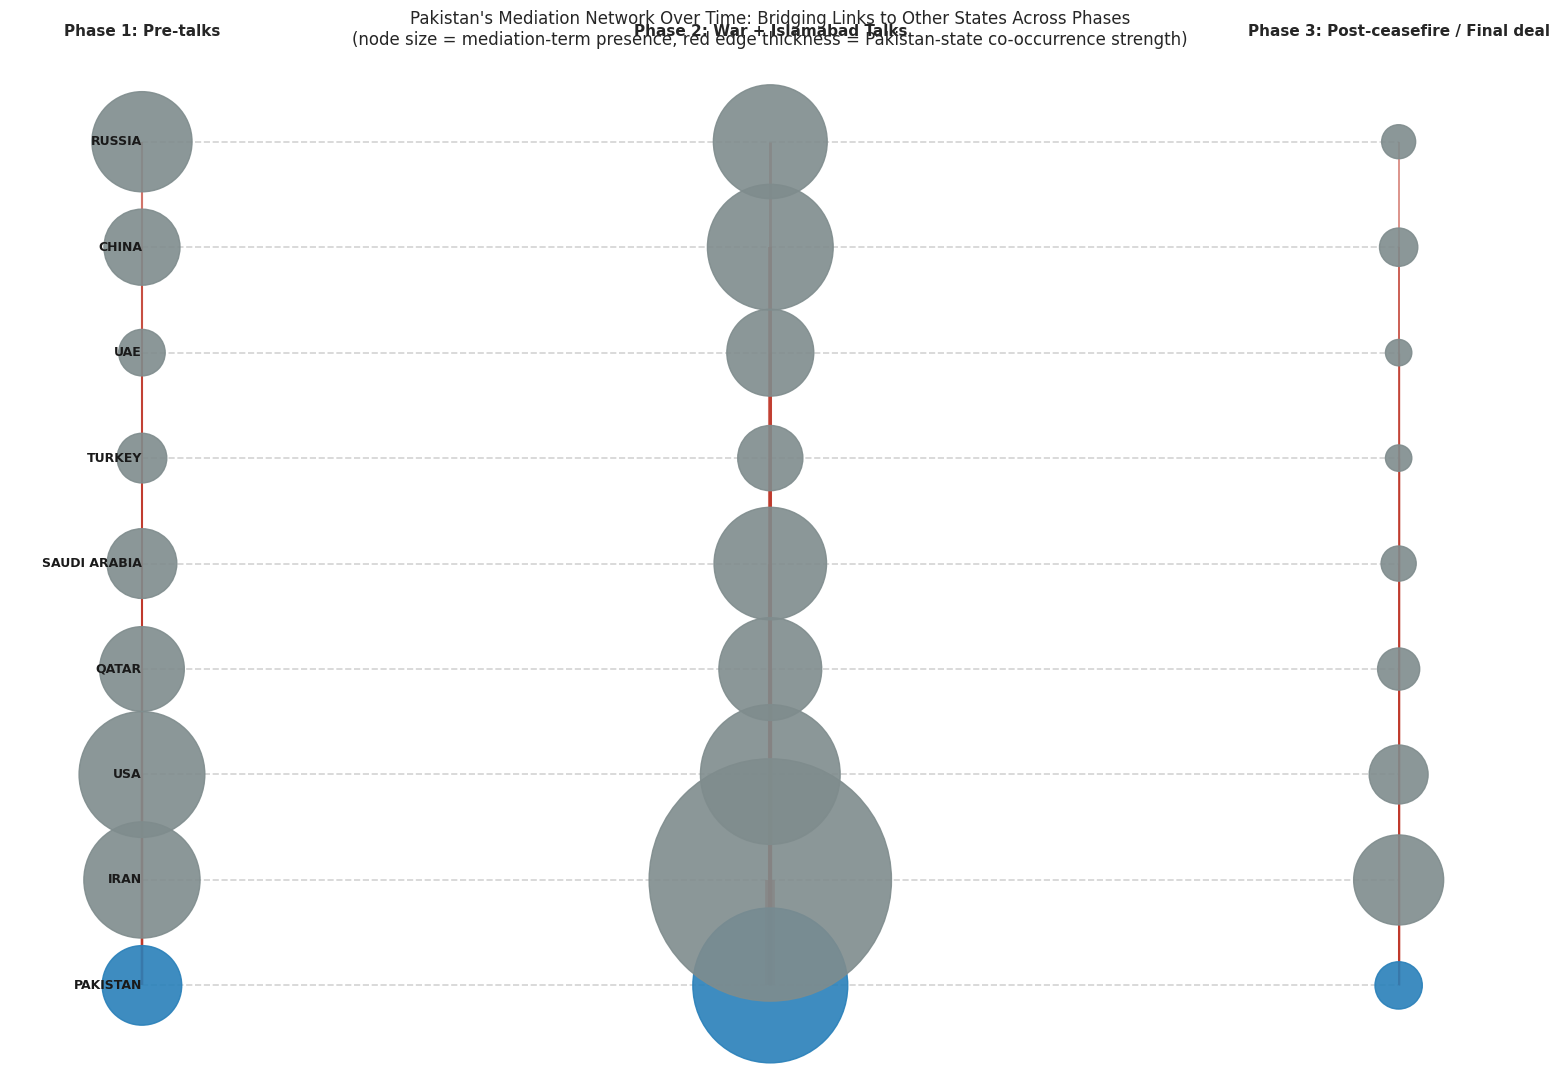

In [19]:
fig, ax = plt.subplots(figsize=(16, 11))

# Layout: x = phase index, y = fixed per-state row (so timeline reads left -> right)
state_y = {state: i for i, state in enumerate(states)}
phase_x = {phase: i * 5 for i, phase in enumerate(phase_list)}

pos = {}
for (state, phase_label) in G.nodes():
    pos[(state, phase_label)] = (phase_x[phase_label], state_y[state])

# Draw continuity edges (same state across phases) - thin dashed grey
continuity_edges = [(u, v) for u, v, d in G.edges(data=True) if d['kind'] == 'continuity']
nx.draw_networkx_edges(G, pos, edgelist=continuity_edges, ax=ax, edge_color='lightgrey',
                        style='dashed', width=1.2, arrows=False)

# Draw bridge edges (Pakistan <-> state within a phase) - thickness = strength
bridge_edges = [(u, v) for u, v, d in G.edges(data=True) if d['kind'] == 'bridge']
weights = [G[u][v]['weight'] for u, v in bridge_edges]
max_w = max(weights) if weights else 1
widths = [1 + 6 * (w / max_w) for w in weights]
nx.draw_networkx_edges(G, pos, edgelist=bridge_edges, ax=ax, edge_color='#c0392b',
                        width=widths, alpha=0.7, arrows=False)

# Node sizes scaled by mediation-term strength
sizes = [200 + 40 * node_strength[n] for n in G.nodes()]
node_colors = ['#2980b9' if state == 'PAKISTAN' else '#7f8c8d' for state, _ in G.nodes()]
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=sizes, node_color=node_colors, alpha=0.9)

# Labels: state name only on the first phase column to avoid repetition
labels = {n: n[0] if n[1] == phase_list[0] else '' for n in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, font_size=9, font_weight='bold',
                         horizontalalignment='right')

# Phase column headers
for phase_label, x in phase_x.items():
    ax.text(x, len(states), phase_label, ha='center', fontsize=11, fontweight='bold')

ax.set_title("Pakistan's Mediation Network Over Time: Bridging Links to Other States Across Phases\n"
              "(node size = mediation-term presence, red edge thickness = Pakistan-state co-occurrence strength)",
              fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.show()


## 13. Notes on This Revision

Changes made:

1. **No concatenation** — Dawn and Guardian are kept as two independent dataframes (`df_dawn`, `df_guardian`) throughout, with every matrix, table, and chart computed per outlet rather than on a pooled dataset.
2. **IRAN/USA filtering** — both datasets are filtered down to only articles whose body mentions IRAN or USA (case-insensitive, also matching "U.S.", "USA", and "United States" variants), discarding unrelated coverage (UK politics, sport, obituaries, etc.) before any further analysis.
3. **CSV export** — the filtered datasets are saved as `dawn_intl_iran_usa_filtered.csv` and `guardian_news_iran_usa_filtered.csv` for upload to the GitHub repo.
4. **Pakistan affiliation table** — Section 8 computes Pakistan's co-occurrence with conflict-party, mediation, and trade terms across the three phases, separately for each outlet, all on the filtered data.
5. **Free-text word-frequency section (Section 9, plus 9.1 visualization)** — extracts actual word frequencies directly from article bodies per phase (not the fixed keyword list), then surfaces words distinctive to each of the three phases vs. words shared across all three, after filtering standard English stopwords and a custom Pakistan-news boilerplate list.
6. **Influence Index (Section 10)** — co-occurrence-frequency-based influence index per phase, computed separately for each outlet.
7. **Network tree (Section 11)** builds a single combined timeline network (Dawn + Guardian filtered data pooled just for this graph, since the network is meant to represent overall mediation discourse rather than an outlet comparison) showing Pakistan's bridging links to other state actors within each phase, plus dashed continuity edges tracking each state across phases left to right.

**Note on the network tree's data source:** Sections 1–10 strictly keep Dawn and Guardian separate. Section 12 is the one exception — it pools the two filtered datasets together, because a *combined* timeline network needs one shared graph rather than two separate trees.
